In [1]:
# ------------------------
# IMPORTS
# ------------------------

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

from src.embedding.netlsd import NetLSD
from src.embedding.feather import FEATHERG
from src.embedding.gnn_model import GNNGraphEncoder

In [2]:
# ============================================================
# Graph Embedding Comparison Notebook
# NetLSD vs FEATHERG vs GNN
# ============================================================

# ------------------------
# GLOBAL CONFIGURATION
# ------------------------

SEED = 42
NUM_GRAPHS = 6
NUM_NODES = 8
EDGE_PROB = 0.4 

EMBEDDING_DIM = 500

# NetLSD
NETLSD_SCALE_STEPS = 500
NETLSD_APPROX = 50

# FEATHER
FEATHER_ORDER = 5
FEATHER_EVAL_POINTS = 25
FEATHER_THETA_MAX = 2.5
FEATHER_POOLING = "mean"

# GNN
GNN_MODEL_PATH = "models/gnn_graph_encoder_contrastive.pt"
HIDDEN_DIM = 128
NUM_LAYERS = 3
NODE_FEATURE_DIM = 4


# Perturbation
PERTURB_RATE = 0.1

np.random.seed(SEED)

In [3]:
# ------------------------
# UTILITY FUNCTIONS
# ------------------------

def force_dim(embeddings, target_dim):
    fixed = []
    for emb in embeddings:
        if emb.shape[0] > target_dim:
            emb = emb[:target_dim]
        elif emb.shape[0] < target_dim:
            emb = np.pad(emb, (0, target_dim - emb.shape[0]))
        fixed.append(emb)
    return np.array(fixed)


def perturb_graph(G, p=0.1):
    Gp = G.copy()
    nodes = list(Gp.nodes())

    for u, v in list(Gp.edges()):
        if np.random.rand() < p:
            Gp.remove_edge(u, v)

    for _ in range(int(p * len(nodes))):
        u, v = np.random.choice(nodes, 2, replace=False)
        Gp.add_edge(u, v)

    return Gp


def nx_to_pyg(graph):
    data = from_networkx(graph)
    data.x = torch.tensor(
        np.vstack([graph.nodes[n]["x"] for n in graph.nodes()]),
        dtype=torch.float,
    )
    return data

In [4]:
# ------------------------
# GRAPH GENERATION
# ------------------------

graphs = []

for _ in range(NUM_GRAPHS):
    G = nx.erdos_renyi_graph(NUM_NODES, EDGE_PROB)

    for u, v in G.edges():
        G[u][v]["weight"] = np.random.uniform(0.5, 2.0)

    # node features for GNN
    for n in G.nodes():
        G.nodes[n]["x"] = np.random.randn(NODE_FEATURE_DIM)

    graphs.append(G)

print(f"Generated {NUM_GRAPHS} graphs with {NUM_NODES} nodes each.")

Generated 6 graphs with 8 nodes each.


In [5]:
# ------------------------
# NetLSD EMBEDDINGS
# ------------------------

netlsd = NetLSD(
    scale_steps=NETLSD_SCALE_STEPS,
    approximations=NETLSD_APPROX,
    seed=SEED,
)

netlsd.fit(graphs)
netlsd_emb = force_dim(netlsd.get_embedding(), EMBEDDING_DIM)

print("NetLSD shape:", netlsd_emb.shape)

NetLSD shape: (6, 500)


/home/mrzaizai2k/code_Bao/ADAPT_GPT/src/embedding/embedding_utils.py:65: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(


In [6]:
# ------------------------
# FEATHERG EMBEDDINGS
# ------------------------

feather = FEATHERG(
    theta_max=FEATHER_THETA_MAX,
    eval_points=FEATHER_EVAL_POINTS,
    order=FEATHER_ORDER,
    pooling=FEATHER_POOLING,
)

feather.fit(graphs)
feather_emb = force_dim(feather.get_embedding(), EMBEDDING_DIM)

print("FEATHER shape:", feather_emb.shape)

100%|██████████| 6/6 [00:00<00:00, 934.42it/s]

FEATHER shape: (6, 500)


In [7]:
# ------------------------
# GNN EMBEDDINGS (LOAD MODEL)
# ------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gnn = GNNGraphEncoder(
    in_dim=NODE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS,
).to(device)


gnn.load_state_dict(torch.load(GNN_MODEL_PATH, map_location=device))
gnn.eval()

gnn_embeddings = []

with torch.no_grad():
    for G in graphs:
        data = nx_to_pyg(G).to(device)
        emb = gnn(data.x, data.edge_index, torch.zeros(data.num_nodes, dtype=torch.long).to(device))
        gnn_embeddings.append(emb.squeeze().cpu().numpy())

gnn_emb = force_dim(np.array(gnn_embeddings), EMBEDDING_DIM)

print("GNN shape:", gnn_emb.shape)

/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data_dict[key] = torch.as_tensor(value)


GNN shape: (6, 500)


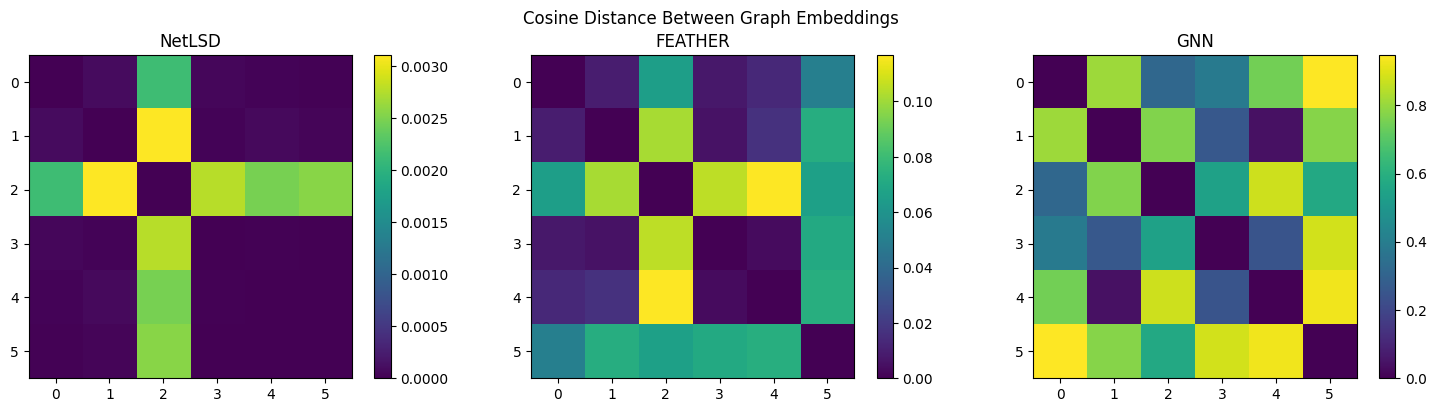

In [8]:
# ------------------------
# PAIRWISE DISTANCE HEATMAPS
# ------------------------

methods = {
    "NetLSD": netlsd_emb,
    "FEATHER": feather_emb,
    "GNN": gnn_emb,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, emb) in zip(axes, methods.items()):
    dist = squareform(pdist(emb, metric="cosine"))
    im = ax.imshow(dist)
    ax.set_title(name)
    plt.colorbar(im, ax=ax)

plt.suptitle("Cosine Distance Between Graph Embeddings")
plt.tight_layout()
plt.show()

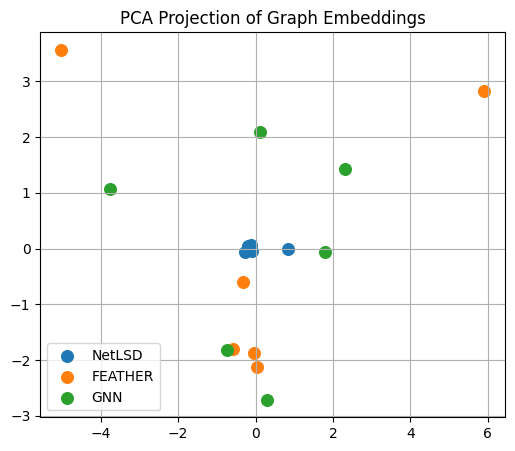

In [9]:
# ------------------------
# PCA VISUALIZATION (2D)
# ------------------------

plt.figure(figsize=(6, 5))

for name, emb in methods.items():
    emb_2d = PCA(n_components=2).fit_transform(emb)
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], label=name, s=70)

plt.legend()
plt.title("PCA Projection of Graph Embeddings")
plt.grid(True)
plt.show()

In [10]:
# ------------------------
# EMBEDDING VARIANCE ANALYSIS
# ------------------------

for name, emb in methods.items():
    var = np.mean(np.std(emb, axis=0))
    print(f"{name} mean per-dimension std: {var:.6f}")

NetLSD mean per-dimension std: 0.011655
FEATHER mean per-dimension std: 0.163826
GNN mean per-dimension std: 0.113944


In [11]:
# ------------------------
# STABILITY UNDER PERTURBATION
# ------------------------

perturbed_graphs = [perturb_graph(G, PERTURB_RATE) for G in graphs]

# NetLSD
netlsd_p = NetLSD(
    scale_steps=NETLSD_SCALE_STEPS,
    approximations=NETLSD_APPROX,
    seed=SEED,
)
netlsd_p.fit(perturbed_graphs)
netlsd_shift = np.linalg.norm(
    netlsd_emb - force_dim(netlsd_p.get_embedding(), EMBEDDING_DIM),
    axis=1
)

# FEATHER
feather_p = FEATHERG(
    theta_max=FEATHER_THETA_MAX,
    eval_points=FEATHER_EVAL_POINTS,
    order=FEATHER_ORDER,
    pooling=FEATHER_POOLING,
)
feather_p.fit(perturbed_graphs)
feather_shift = np.linalg.norm(
    feather_emb - force_dim(feather_p.get_embedding(), EMBEDDING_DIM),
    axis=1
)

# GNN
gnn_shift = []

with torch.no_grad():
    for G in perturbed_graphs:
        data = nx_to_pyg(G).to(device)
        emb = gnn(data.x, data.edge_index, torch.zeros(data.num_nodes, dtype=torch.long).to(device))
        gnn_shift.append(emb.squeeze().cpu().numpy())

gnn_shift = np.linalg.norm(
    gnn_emb - force_dim(np.array(gnn_shift), EMBEDDING_DIM),
    axis=1
)

/home/mrzaizai2k/code_Bao/ADAPT_GPT/src/embedding/embedding_utils.py:65: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(
100%|██████████| 6/6 [00:00<00:00, 1314.35it/s]


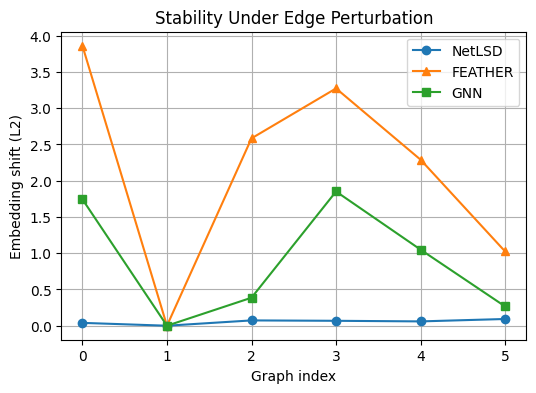

In [12]:
# ------------------------
# STABILITY PLOT
# ------------------------

plt.figure(figsize=(6, 4))
plt.plot(netlsd_shift, marker="o", label="NetLSD")
plt.plot(feather_shift, marker="^", label="FEATHER")
plt.plot(gnn_shift, marker="s", label="GNN")
plt.xlabel("Graph index")
plt.ylabel("Embedding shift (L2)")
plt.title("Stability Under Edge Perturbation")
plt.legend()
plt.grid(True)
plt.show()